# Data Pipeline — Example Usage

Demonstrates the Phase 1 data utilities:
- `Universe` — asset universe management
- `YFinanceConnector` — fetch OHLCV and fundamental data
- `cached_fetch` — local parquet cache with TTL
- `fetch_price_history` — unified loader interface
- Multi-symbol fetching + visualisation

> **Note:** This notebook uses real `yfinance` calls for illustration.
> No API keys or credentials are required.
> **Clear all outputs before committing** (`Cell → All Output → Clear`).

In [1]:
import sys
from pathlib import Path

# Make the package importable when running from examples/notebooks/
repo_root = Path().resolve().parents[1]
src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Repo root : {repo_root}")
print(f"src on path: {src_path}")

Repo root : /Users/jiahuiwu/projects/quant-trading
src on path: /Users/jiahuiwu/projects/quant-trading/src


## 1. Universe Management

`Universe` is a strategy-agnostic container for ticker symbols.
The private repository supplies the real symbol lists; here we use a small illustrative set.

In [2]:
from quant_trading.data.universe import Universe

# Duplicate symbol is intentional — Universe deduplicates automatically
tech = Universe(
    name="tech_sample",
    symbols=["AAPL", "MSFT", "GOOGL", "AAPL"],
    metadata={"asset_class": "equity", "sector": "technology"},
)
print(tech)
print(f"Symbols : {tech.symbols}")
print(f"Length  : {len(tech)}")
print(f"'MSFT' in universe: {'MSFT' in tech}")
print(f"'TSLA' in universe: {'TSLA' in tech}")

Universe 'tech_sample': 1 duplicate symbol(s) removed.


Universe(name='tech_sample', n=3)
Symbols : ['AAPL', 'MSFT', 'GOOGL']
Length  : 3
'MSFT' in universe: True
'TSLA' in universe: False


In [3]:
# filter, exclude, union
small = tech.filter(["AAPL", "MSFT"])
print(f"filter(['AAPL','MSFT']) → {small.symbols}")

no_apple = tech.exclude(["AAPL"])
print(f"exclude(['AAPL'])       → {no_apple.symbols}")

finance = Universe(name="finance_sample", symbols=["JPM", "GS"])
combined = tech.union(finance)
print(f"union(finance_sample)  → {combined.symbols}")

filter(['AAPL','MSFT']) → ['AAPL', 'MSFT']
exclude(['AAPL'])       → ['MSFT', 'GOOGL']
union(finance_sample)  → ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'GS']


## 2. Fetch OHLCV Data — YFinanceConnector

Direct use of the connector. No API key required.
Returns a UTC-indexed DataFrame with normalised lower-case column names.

In [15]:
from datetime import datetime, timezone
from quant_trading.data.apis.yfinance_connector import YFinanceConnector

connector = YFinanceConnector()

START = datetime(2024, 1, 1, tzinfo=timezone.utc)
END   = datetime(2024, 6, 30, tzinfo=timezone.utc)

df_aapl = connector.fetch_price_history("AAPL", start=START, end=END, freq="1d")

print(f"Shape   : {df_aapl.shape}")
print(f"Columns : {df_aapl.columns.tolist()}")
print(f"Index tz: {df_aapl.index.tzinfo}")
df_aapl.head()

Shape   : (124, 5)
Columns : ['open', 'high', 'low', 'close', 'volume']
Index tz: UTC


,open,high,low,close,volume
Date,,,,,
2024-01-02 05:00:00+00:00,185.225762,186.502507,181.999286,183.731293,82488700
2024-01-03 05:00:00+00:00,182.325900,183.968836,181.544015,182.355591,58414500
2024-01-04 05:00:00+00:00,180.277180,181.207518,179.020249,180.039658,71983600
2024-01-05 05:00:00+00:00,180.118854,180.880926,178.317559,179.317169,62379700
2024-01-08 05:00:00+00:00,180.217791,183.691712,179.633861,183.652115,59144500


Rows: 124
Close min/max: 163.51193237304688 215.00714111328125
Close nulls: 0


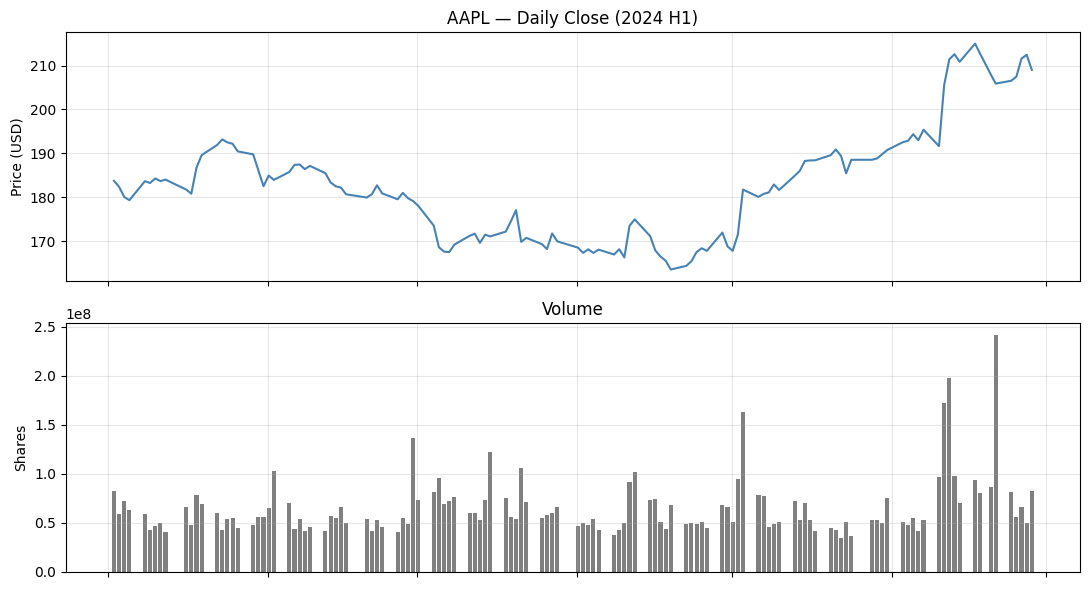

In [17]:
# debug-safe plotting for AAPL close + volume
import matplotlib.pyplot as plt
import numpy as np

# ensure numeric and drop rows missing both series
df_plot = df_aapl.copy()
df_plot["close"] = pd.to_numeric(df_plot["close"], errors="coerce")
df_plot["volume"] = pd.to_numeric(df_plot["volume"], errors="coerce")
df_plot = df_plot.dropna(subset=["close", "volume"], how="all").sort_index()

# quick diagnostics
print("Rows:", len(df_plot))
print("Close min/max:", np.nanmin(df_plot["close"]), np.nanmax(df_plot["close"]))
print("Close nulls:", df_plot["close"].isna().sum())

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(df_plot.index, df_plot["close"], color="steelblue", linewidth=1.5)
axes[0].set_title("AAPL — Daily Close (2024 H1)")
axes[0].set_ylabel("Price (USD)")
axes[0].grid(True, alpha=0.3)

axes[1].bar(df_plot.index, df_plot["volume"], color="grey", width=0.8)
axes[1].set_title("Volume")
axes[1].set_ylabel("Shares")
axes[1].grid(True, alpha=0.3)

# hide lower xticks labels if crowded
axes[1].set_xticklabels([])
plt.tight_layout()
plt.show()

## 3. Cache Layer — `cached_fetch`

The first call fetches from the network and writes a local parquet file.
The second call is served directly from disk — no network request.

Cache location: `~/.cache/quant_trading/` (override with `QUANT_CACHE_DIR` env var).
TTL default: 24 hours (override with `QUANT_CACHE_TTL_HOURS` env var).

In [7]:
import time
from quant_trading.data.cache import cached_fetch, invalidate_cache

def _fetch_msft():
    return connector.fetch_price_history("MSFT", start=START, end=END, freq="1d")

# First call — network fetch + cache write
t0 = time.perf_counter()
df_msft = cached_fetch(_fetch_msft, symbol="MSFT", start=START, end=END, freq="1d", source="yfinance")
t_first = (time.perf_counter() - t0) * 1000

# Second call — cache HIT
t1 = time.perf_counter()
df_msft_cached = cached_fetch(_fetch_msft, symbol="MSFT", start=START, end=END, freq="1d", source="yfinance")
t_second = (time.perf_counter() - t1) * 1000

print(f"First call  (network + write) : {t_first:.0f} ms")
print(f"Second call (cache HIT)        : {t_second:.0f} ms")
print(f"Speedup                        : {t_first / max(t_second, 0.1):.1f}x")

First call  (network + write) : 1955 ms
Second call (cache HIT)        : 40 ms
Speedup                        : 48.3x


In [8]:
# Manually invalidate a cache entry (e.g. after a vendor data correction)
removed = invalidate_cache(symbol="MSFT", start=START, end=END, freq="1d", source="yfinance")
print(f"Cache entry deleted: {removed}")

Cache entry deleted: True


## 4. Unified Loader — `fetch_price_history`

Recommended entry point for all callers.
Wires together connector selection, caching, and normalisation in one call.

In [9]:
from quant_trading.data.loaders import fetch_price_history

df_googl = fetch_price_history(
    symbol="GOOGL",
    start=START,
    end=END,
    freq="1d",
    source="yfinance",
    cache=True,
)
print(f"GOOGL — {len(df_googl)} rows, {df_googl.shape[1]} columns")
df_googl.tail()

GOOGL — 124 rows, 5 columns


,open,high,low,close,volume
Date,,,,,
2024-06-24 04:00:00+00:00,178.888247,179.613089,177.408759,177.954880,18298000
2024-06-25 04:00:00+00:00,178.352083,182.989116,178.153498,182.730957,23130200
2024-06-26 04:00:00+00:00,181.340840,183.207559,181.191889,182.582016,19839000
2024-06-27 04:00:00+00:00,182.879898,184.736709,182.721039,184.101227,18848900
2024-06-28 04:00:00+00:00,183.018908,183.823187,180.675566,180.864212,29156600


## 5. Multi-Symbol Fetch via Universe

Iterate a `Universe` to build a stacked close-price DataFrame —
a common input pattern for signal generators and the portfolio optimizer.

In [10]:
import pandas as pd

# Universe is iterable — the private repo would supply the real symbol list
prices: dict[str, pd.Series] = {}

for symbol in small:   # small = ["AAPL", "MSFT"]
    df = fetch_price_history(symbol=symbol, start=START, end=END, freq="1d", cache=True)
    prices[symbol] = df["close"]
    print(f"  {symbol}: {len(df)} rows fetched")

close_prices = pd.DataFrame(prices)
print(f"\nStacked close prices shape: {close_prices.shape}")
close_prices.tail()

  AAPL: 124 rows fetched
  MSFT: 124 rows fetched

Stacked close prices shape: (124, 2)


,AAPL,MSFT
Date,,
2024-06-24 04:00:00+00:00,206.542587,441.698029
2024-06-25 04:00:00+00:00,207.465469,444.934265
2024-06-26 04:00:00+00:00,211.613373,446.128052
2024-06-27 04:00:00+00:00,212.456879,446.808899
2024-06-28 04:00:00+00:00,209.003555,440.987610


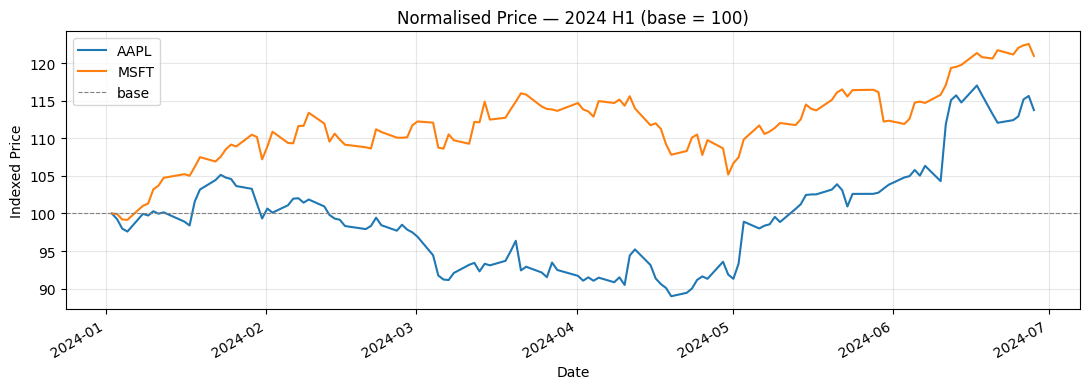

In [11]:
# Normalised cumulative return (base = 100 on first trading day)
norm = (close_prices / close_prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(11, 4))
norm.plot(ax=ax, title="Normalised Price — 2024 H1 (base = 100)", ylabel="Indexed Price")
ax.axhline(100, color="grey", linestyle="--", linewidth=0.8, label="base")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Fetch Fundamentals

`fetch_fundamentals` returns a snapshot of key fundamental metrics for a symbol.
Available fields depend on Yahoo Finance coverage and may change without notice.

In [12]:
from quant_trading.data.loaders import fetch_fundamentals

fund = fetch_fundamentals("AAPL", source="yfinance")
fund.T   # transpose for easier reading in notebook

,0
symbol,AAPL
shortName,Apple Inc.
sector,Technology
industry,Consumer Electronics
marketCap,3979469914112
trailingPE,34.35488
forwardPE,28.92041
priceToBook,45.19173
trailingEps,7.89
dividendYield,0.38


## 7. Load Fama-French Factor Returns

`FamaFrenchConnector` wraps `pandas_datareader`'s Kenneth French Data Library to fetch
daily factor returns as decimals.  Three factor families are supported out of the box:

| Family | Factors |
|---|---|
| `FF3` | Mkt-RF, SMB, HML |
| `FF5` | Mkt-RF, SMB, HML, RMW, CMA |
| `CARHART4` | Mkt-RF, SMB, HML, MOM |

**Note:** These are freely available academic data — no API key required.
The connector caches results in-process so repeated calls within a session are instant.

In [9]:
from quant_trading.data.apis.fama_french_connector import FamaFrenchConnector
from quant_trading.optim.factor import FACTOR_FAMILIES

connector_ff = FamaFrenchConnector()

# Fetch FF3 daily factor returns
ff3 = connector_ff.fetch_factor_returns(
    family=FACTOR_FAMILIES.FF3,
    start="2026-01-01",
    end="2026-12-31",
)

print(f"FF3 shape: {ff3.shape}")
print(f"Date range: {ff3.index.min().date()} → {ff3.index.max().date()}")
print(f"Columns: {list(ff3.columns)}")
ff3.tail()

FF3 shape: (39, 3)
Date range: 2026-01-02 → 2026-02-27
Columns: ['Mkt-RF', 'SMB', 'HML']


,Mkt-RF,SMB,HML
Date,,,
2026-02-23,-0.0118,-0.0030,-0.0131
2026-02-24,0.0083,0.0051,-0.0066
2026-02-25,0.0079,-0.0037,0.0049
2026-02-26,-0.0047,0.0063,0.0032
2026-02-27,-0.0051,-0.0044,-0.0125


In [5]:
import numpy as np
import pandas as pd

factor_stats = pd.DataFrame({
    "Ann. Return (%)": ff3.mean() * 252 * 100,
    "Ann. Vol (%)":    ff3.std() * np.sqrt(252) * 100,
}).round(2)
factor_stats["Sharpe"] = (factor_stats["Ann. Return (%)"] / factor_stats["Ann. Vol (%)"]).round(2)
factor_stats

,Ann. Return (%),Ann. Vol (%),Sharpe
Mkt-RF,18.97,13.43,1.41
SMB,-4.94,11.63,-0.42
HML,-9.08,11.95,-0.76


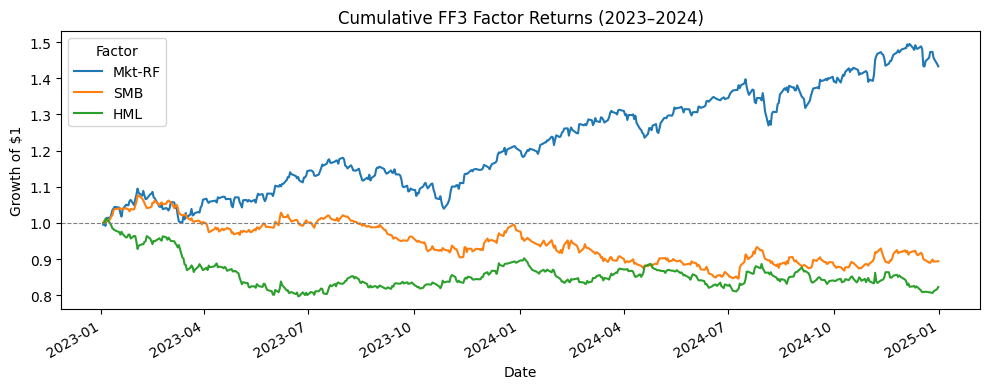

In [6]:
# Plot cumulative factor returns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
(1 + ff3).cumprod().plot(ax=ax)
ax.set_title("Cumulative FF3 Factor Returns (2023–2024)")
ax.set_ylabel("Growth of $1")
ax.axhline(1, color="grey", linewidth=0.8, linestyle="--")
ax.legend(title="Factor")
plt.tight_layout()
plt.show()

RF annualised (approx): 5.04%


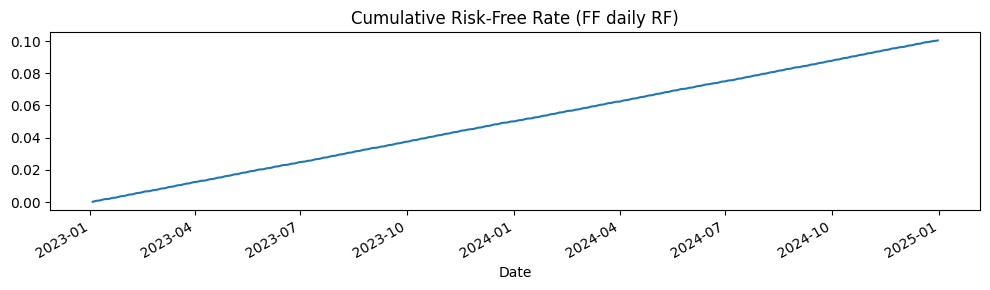

In [7]:
# Also fetch the risk-free rate (RF) separately
rf = connector_ff.fetch_risk_free_rate(start="2023-01-01", end="2024-12-31")
print(f"RF annualised (approx): {rf.mean() * 252:.2%}")
rf.cumsum().plot(title="Cumulative Risk-Free Rate (FF daily RF)", figsize=(10, 3))
plt.tight_layout()
plt.show()

## 8. Environment Variable Reference

| Variable | Default | Purpose |
|---|---|---|
| `QUANT_CACHE_DIR` | `~/.cache/quant_trading` | Local parquet cache directory |
| `QUANT_CACHE_TTL_HOURS` | `24` | Cache TTL in hours |

Set in your shell or `.env` file — **never commit the `.env` file**.

```bash
export QUANT_CACHE_DIR=/tmp/quant_cache   # short-lived cache for CI
export QUANT_CACHE_TTL_HOURS=1
```

---

**Next:** See `example_backtest.ipynb` for how to feed this data into the backtesting engine.